# Stage 2 — SpatialConfiguration-Net (SC-Net)
## Vertebra Centroid Detection via Multi-Heatmap Regression

**Pipeline Overview:**
1. Load dataset from CSV + JSON centroids (same format as Stage 3)
2. Preprocess: resample → 2.0 mm isotropic, Gaussian smooth σ=0.75, normalise ÷2048 clamp[-1,1]
3. Simulate Stage-1 output: centre X,Y on spine mean; random Z-crop to (96×96×128) during training
4. SC-Net architecture: Local-Appearance (U-Net-like, 5 levels, 64 filters, 3×3×3) +
   Spatial-Configuration branch (at 1/4 res, four 7×7×7 convs) → N=25 predicted heatmaps
5. Modified L2 loss with **dynamically-generated GT heatmaps** and **learned σ per vertebra**
   (+ α=100 sigma-penalty to prevent sigma collapse)
6. Nesterov SGD: lr=1e-8, momentum=0.9, weight_decay=5e-4, 100 000 iterations

**Key difference from Stage 3:**
- Stage 3 processes ONE vertebra at a time (per-vertebra binary segmentation)
- Stage 2 processes the FULL SPINE in one forward pass, predicting 25 heatmaps simultaneously

## 1. Imports

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import nibabel as nib
import nibabel.orientations as nib_ornt
import scipy.ndimage as ndi
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.ndimage import gaussian_filter, zoom

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Nibabel version:", nib.__version__)
print("All imports successful ✓")

PyTorch version: 2.9.0+cu126
CUDA available: True
Nibabel version: 5.3.3
All imports successful ✓


## 2. Configuration & Hyperparameters

All values taken directly from the Stage 2 description.

In [2]:
CFG = {
    # ── Paths ────────────────────────────────────────────────────
    "csv_path":        "/kaggle/input/datasets/ahmed226/verse19-csv/verse19_dataset.csv",
    "checkpoint_path": "/kaggle/working/best_model_stage2.pth",
    "resume_path":     "/kaggle/input/models/ahmedsayad226/seg-stage-2/pytorch/default/1/best_model_stage2.pth",

    # ── Preprocessing (Stage 2 paper values) ─────────────────────
    "target_spacing":   2.0,    # mm — isotropic (vs 1.0 in Stage 3)
    "smooth_sigma":     0.75,   # Gaussian σ for volume smoothing
    "intensity_divisor": 2048.0,
    "intensity_clamp":   1.0,   # clamp range [-1, 1]

    # ── Crop ─────────────────────────────────────────────────────
    # (96, 96, 128) = (X, Y, Z) as per description
    # Axes after RAS reorientation: axis-0=R(X), axis-1=A(Y), axis-2=S(Z)
    # X and Y are centred on spine mean; Z is a random crop during training
    "crop_size":  (96, 96, 128),   # (X, Y, Z)

    # ── SC-Net / Heatmap ─────────────────────────────────────────
    "max_vertebrae": 25,    # C1-L6 label range mapped to 0-24 indices
    # Vertebra labels in VerSe19: 1=C1 … 7=C7, 8=T1 … 19=T12, 20=L1 … 25=L6
    # We map label -> index as (label - 1) so index ∈ [0, 24]
    "sigma_init":   5.0,    # initial value for learned sigmas
    "alpha":       100.0,   # penalty factor for learned sigmas

    # ── Training ─────────────────────────────────────────────────
    "lr":            1e-8,
    "momentum":      0.9,
    "nesterov":      True,
    "weight_decay":  5e-4,
    "batch_size":    1,
    "iterations":    50_000,
    "log_every":     200,
    "val_every":     1000,

    # ── Device ───────────────────────────────────────────────────
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

print("Configuration loaded:")
for k, v in CFG.items():
    print(f"  {k:25s}: {v}")

Configuration loaded:
  csv_path                 : /kaggle/input/datasets/ahmed226/verse19-csv/verse19_dataset.csv
  checkpoint_path          : /kaggle/working/best_model_stage2.pth
  resume_path              : /kaggle/input/models/ahmedsayad226/seg-stage-2/pytorch/default/1/best_model_stage2.pth
  target_spacing           : 2.0
  smooth_sigma             : 0.75
  intensity_divisor        : 2048.0
  intensity_clamp          : 1.0
  crop_size                : (96, 96, 128)
  max_vertebrae            : 25
  sigma_init               : 5.0
  alpha                    : 100.0
  lr                       : 1e-08
  momentum                 : 0.9
  nesterov                 : True
  weight_decay             : 0.0005
  batch_size               : 1
  iterations               : 50000
  log_every                : 200
  val_every                : 1000
  device                   : cuda


## 3. Data Loading from CSV & JSON

Identical format to Stage 3 — reusing the same helpers.

In [3]:
def parse_centroid_json(json_path):
    """
    Parse the VerSe centroid JSON file.
    Returns:
        direction : list[str]  e.g. ['P','I','R']
        centroids : dict  {label_int: (X, Y, Z)}
    """
    with open(json_path, "r") as f:
        data = json.load(f)
    direction = data[0].get("direction", [])
    centroids = {}
    for entry in data[1:]:
        label = int(entry["label"])
        centroids[label] = (float(entry["X"]), float(entry["Y"]), float(entry["Z"]))
    return direction, centroids


def _is_valid_path(val):
    """Return True if val is a non-empty, non-NaN string."""
    if val is None:
        return False
    try:
        if isinstance(val, float):
            return False
        return isinstance(val, str) and val.strip() != ""
    except Exception:
        return False


def load_subject(row):
    """
    Load a single subject from a CSV row.
    Returns a dict with nibabel image objects + parsed centroids,
    or raises ValueError with a descriptive message.
    """
    required = {"image_path": row.get("image_path"),
                "centroid_json_path": row.get("centroid_json_path")}
    for col, val in required.items():
        if not _is_valid_path(val):
            raise ValueError(f"Column '{col}' is missing or NaN for subject '{row.get('name', '?')}'")

    volume_nib = nib.load(str(row["image_path"]))

    mask_nib = None
    if _is_valid_path(row.get("mask_path")):
        mask_nib = nib.load(str(row["mask_path"]))
    else:
        print(f"  ⚠ No mask_path for {row.get('name', '?')} — mask will be None")

    direction, centroids = parse_centroid_json(str(row["centroid_json_path"]))
    return {
        "name":      row["name"],
        "type":      row["type"],
        "volume":    volume_nib,
        "mask":      mask_nib,
        "direction": direction,
        "centroids": centroids,
    }


# ── Load CSV ─────────────────────────────────────────────────────────────────
df = pd.read_csv(CFG["csv_path"])
print("CSV loaded — columns:", list(df.columns))
print(df.to_string(index=False))

# ── Load all subjects ────────────────────────────────────────────────────────
subjects = []
for _, row in df.iterrows():
    try:
        subj = load_subject(row)
        subjects.append(subj)
        print(f"\n✓ Loaded subject: {subj['name']}  [{subj['type']}]")
        print(f"  Volume shape : {subj['volume'].shape}  | spacing: {subj['volume'].header.get_zooms()}")
        print(f"  Vertebrae    : {sorted(subj['centroids'].keys())}")
    except ValueError as e:
        print(f"  ✗ Skipped: {e}")
    except FileNotFoundError as e:
        print(f"  ✗ Missing file: {e}")

print("\n── Dataset split summary ──────────────────────────────")
print(df.groupby("type").size().rename("subjects").to_frame())

CSV loaded — columns: ['name', 'type', 'image_path', 'mask_path', 'centroid_json_path']
                   name  type                                                                                                                                image_path                                                                                                                                               mask_path                                                                                                                                     centroid_json_path
               verse004 train                  /kaggle/input/datasets/devanshdesai7/verse-19-3d-images/dataset-verse19training/rawdata/sub-verse004/sub-verse004_ct.nii                  /kaggle/input/datasets/devanshdesai7/verse-19-3d-images/dataset-verse19training/derivatives/sub-verse004/sub-verse004_seg-vert_msk.nii                  /kaggle/input/datasets/devanshdesai7/verse-19-3d-images/dataset-verse19training/derivatives/sub-verse004


✓ Loaded subject: verse004  [train]
  Volume shape : (161, 338, 61)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(2.000296))
  Vertebrae    : [16, 17, 18, 19, 20, 21, 22, 23, 24]

✓ Loaded subject: verse006  [train]
  Volume shape : (915, 1189, 121)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(3.0))
  Vertebrae    : [23, 24]



✓ Loaded subject: verse007  [train]
  Volume shape : (250, 325, 38)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(3.0))
  Vertebrae    : [16, 17, 18, 19, 20, 21, 22]

✓ Loaded subject: verse008  [train]
  Volume shape : (269, 269, 73)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.9965007))
  Vertebrae    : [19, 20, 21, 22, 23, 24]



✓ Loaded subject: verse009  [train]
  Volume shape : (459, 459, 66)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(2.0))
  Vertebrae    : [9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

✓ Loaded subject: verse010  [val]
  Volume shape : (186, 206, 186)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
  Vertebrae    : [20, 21, 22, 23, 24]



✓ Loaded subject: verse011  [val]
  Volume shape : (289, 289, 38)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.9999335))
  Vertebrae    : [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
  ⚠ No mask_path for verse012 — mask will be None

✓ Loaded subject: verse012  [test]
  Volume shape : (194, 252, 35)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(3.0000002))
  Vertebrae    : [17, 18, 19, 20, 21, 22]


...


✓ Loaded subject: verse408_split-verse265  [train]
  Volume shape : (250, 250, 571)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
  Vertebrae    : [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

✓ Loaded subject: verse409_split-verse226  [train]
  Volume shape : (287, 287, 270)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
  Vertebrae    : [2, 3, 4, 5, 6, 7, 8, 9]

✓ Loaded subject: verse409_split-verse266  [train]
  Volume shape : (222, 222, 589)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
  Vertebrae    : [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

✓ Loaded subject: verse410_split-verse227  [train]
  Volume shape : (257, 257, 214)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
  Vertebrae    : [2, 3, 4, 5, 6, 7, 8]



✓ Loaded subject: verse410_split-verse267  [train]
  Volume shape : (208, 208, 543)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
  Vertebrae    : [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

✓ Loaded subject: verse411_split-verse232  [train]
  Volume shape : (173, 173, 184)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
  Vertebrae    : [2, 3, 4, 5, 6, 7, 8]

✓ Loaded subject: verse411_split-verse270  [train]
  Volume shape : (317, 317, 559)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
  Vertebrae    : [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

✓ Loaded subject: verse412_split-verse235  [val]
  Volume shape : (205, 205, 255)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
  Vertebrae    : [2, 3, 4, 5, 6, 7, 8, 9]



✓ Loaded subject: verse412_split-verse290  [val]
  Volume shape : (250, 250, 671)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
  Vertebrae    : [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

✓ Loaded subject: verse413_split-verse239  [train]
  Volume shape : (182, 182, 258)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
  Vertebrae    : [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

✓ Loaded subject: verse413_split-verse272  [train]
  Volume shape : (209, 209, 603)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
  Vertebrae    : [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]



✓ Loaded subject: verse414_split-verse273  [test]
  Volume shape : (157, 522, 44)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(3.0))
  Vertebrae    : [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

✓ Loaded subject: verse415_split-verse243  [train]
  Volume shape : (160, 213, 61)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.9993935))
  Vertebrae    : [2, 3, 4, 5, 6, 7, 8]

✓ Loaded subject: verse415_split-verse275  [train]
  Volume shape : (179, 692, 88)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(2.0))
  Vertebrae    : [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

✓ Loaded subject: verse416_split-verse247  [test]
  Volume shape : (159, 171, 46)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.9996402))
  Vertebrae    : [2, 3, 4, 5, 6, 7, 8]



✓ Loaded subject: verse416_split-verse279  [test]
  Volume shape : (512, 512, 91)  | spacing: (np.float32(1.2807554), np.float32(1.2807554), np.float32(1.9999996))
  Vertebrae    : [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

✓ Loaded subject: verse417_split-verse277  [test]
  Volume shape : (170, 419, 48)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.9995612))
  Vertebrae    : [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

✓ Loaded subject: verse417_split-verse278  [test]
  Volume shape : (148, 308, 71)  | spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.9994699))
  Vertebrae    : [18, 19, 20, 21, 22, 23, 24]

── Dataset split summary ──────────────────────────────
       subjects
type           
test         37
train        76
val          38


## 4. Preprocessing Pipeline

Steps (identical approach to Stage 3 but at **2.0 mm** spacing):
1. Reorient to RAS+
2. Resample to **2.0 mm** isotropic
3. Gaussian smooth σ=0.75
4. Normalise: ÷2048, clamp[-1, 1]

In [4]:
# ── Core reorientation helpers (exact copy from Stage 3) ─────────────────────

def reorient_to_ras(nib_img):
    """Reorient a NIfTI image to standard RAS+ orientation."""
    orig_ornt = nib.io_orientation(nib_img.affine)
    ras_ornt  = nib.orientations.axcodes2ornt(("R", "A", "S"))
    transform = nib.orientations.ornt_transform(orig_ornt, ras_ornt)
    return nib_img.as_reoriented(transform)


def resample_volume(vol, current_spacing, target_spacing=2.0, order=1):
    """Resample volume to target isotropic spacing using scipy.ndimage.zoom."""
    zoom_factors = current_spacing / target_spacing
    return zoom(vol, zoom_factors, order=order)


def world_to_voxel(affine, world_xyz):
    """Convert world-space (mm) coordinate → voxel indices."""
    inv_affine = np.linalg.inv(affine)
    vox = inv_affine[:3, :3] @ np.array(world_xyz) + inv_affine[:3, 3]
    return np.round(vox).astype(int)


def full_preprocess(vol_nib, mask_nib=None,
                    target_spacing=2.0, sigma=0.75, divisor=2048.0):
    """
    Full preprocessing pipeline for Stage 2:
        reorient → resample (2mm) → smooth → normalise.
    Returns:
        vol_n        : float32 ndarray, normalised, 2mm isotropic, RAS
        mask_out     : int16   ndarray (zeros if no mask)
        ras_affine   : (4,4) affine of the RAS-reoriented volume
        zooms        : (3,)  spacing BEFORE resampling
        orig_affine  : (4,4) original image affine
    """
    vol_ras    = reorient_to_ras(vol_nib)
    ras_affine = vol_ras.affine.copy()
    zooms      = np.array(vol_ras.header.get_zooms()[:3], dtype=np.float64)
    vol_data   = vol_ras.get_fdata(dtype=np.float32)

    vol_r = resample_volume(vol_data, zooms, target_spacing, order=1)
    vol_s = gaussian_filter(vol_r, sigma=sigma)
    vol_n = np.clip(vol_s / divisor, -1.0, 1.0).astype(np.float32)

    if mask_nib is not None:
        mask_ras  = reorient_to_ras(mask_nib)
        mask_data = mask_ras.get_fdata().astype(np.int16)
        mask_r    = resample_volume(mask_data, zooms, target_spacing, order=0)
        mask_out  = mask_r.astype(np.int16)
    else:
        mask_out = np.zeros(vol_n.shape, dtype=np.int16)

    return vol_n, mask_out, ras_affine, zooms, vol_nib.affine


def centroids_to_voxel_2mm(raw_centroids, original_affine, ras_affine,
                            original_zooms, target_spacing=2.0):
    """
    Convert JSON original voxel centroids → integer voxel indices in the
    2mm-isotropic, RAS-reoriented volume.
    (Same logic as Stage 3 centroids_to_voxel_1mm, but for 2mm.)
    """
    inv_affine = np.linalg.inv(ras_affine)
    result = {}
    for label, (vx, vy, vz) in raw_centroids.items():
        world_pt = original_affine @ np.array([vx, vy, vz, 1.0])
        ras_vox  = inv_affine[:3, :3] @ world_pt[:3] + inv_affine[:3, 3]
        # Scale from original mm → 2mm grid
        vox_2mm  = np.round(ras_vox * (original_zooms / target_spacing)).astype(int)
        result[label] = tuple(vox_2mm)
    return result


# ── Quick demo on the first subject ──────────────────────────────────────────
demo = subjects[0] if subjects else None
if demo is not None:
    vol_pp, mask_pp, ras_affine_demo, zooms_demo, orig_affine_demo = full_preprocess(
        demo["volume"], demo["mask"],
        target_spacing=CFG["target_spacing"],
        sigma=CFG["smooth_sigma"],
        divisor=CFG["intensity_divisor"],
    )
    print(f"Preprocessed volume shape : {vol_pp.shape}  (at 2mm isotropic)")
    print(f"Normalised range          : [{vol_pp.min():.4f}, {vol_pp.max():.4f}]")

    centroids_2mm = centroids_to_voxel_2mm(
        demo["centroids"], orig_affine_demo, ras_affine_demo, zooms_demo,
        target_spacing=CFG["target_spacing"]
    )
    # Override with mask CoM when available (same logic as Stage 3)
    for label in list(centroids_2mm.keys()):
        if np.any(mask_pp == label):
            coords = np.array(np.where(mask_pp == label))
            centroids_2mm[label] = tuple(np.round(coords.mean(axis=1)).astype(int))

    print("\nCentroids at 2mm voxel space:")
    for lbl, vox in sorted(centroids_2mm.items()):
        print(f"  label {lbl:3d}: {vox}")
else:
    print("⚠ No subjects loaded — check CSV paths.")

Preprocessed volume shape : (61, 80, 169)  (at 2mm isotropic)
Normalised range          : [-0.5003, 0.5149]

Centroids at 2mm voxel space:
  label  16: (np.int64(32), np.int64(34), np.int64(148))
  label  17: (np.int64(32), np.int64(35), np.int64(137))
  label  18: (np.int64(31), np.int64(37), np.int64(123))
  label  19: (np.int64(31), np.int64(39), np.int64(108))
  label  20: (np.int64(31), np.int64(41), np.int64(95))
  label  21: (np.int64(30), np.int64(47), np.int64(83))
  label  22: (np.int64(29), np.int64(50), np.int64(67))
  label  23: (np.int64(29), np.int64(50), np.int64(52))
  label  24: (np.int64(28), np.int64(46), np.int64(37))


## 5. Stage-1 Simulation & Random Z-Crop

Stage 1 just finds the spine centre in X and Y.  
During training we **simulate** this by using the mean X,Y of all GT centroids,  
then take a **random** Z-start so the crop window (96×96×128) slides along the spine.

Crop shape   : (96, 96, 128)  (expected (96, 96, 128))
Spine centre : X=30, Y=42
Z start      : 3  (Z window [3, 131))

Crop-space centroids (Z inside window iff 0 ≤ ck < 128):
  label  16: (  50,   40,  145)  ✗ outside Z window
  label  17: (  50,   41,  134)  ✗ outside Z window
  label  18: (  49,   43,  120)  ✓ in window
  label  19: (  49,   45,  105)  ✓ in window
  label  20: (  49,   47,   92)  ✓ in window
  label  21: (  48,   53,   80)  ✓ in window
  label  22: (  47,   56,   64)  ✓ in window
  label  23: (  47,   56,   49)  ✓ in window
  label  24: (  46,   52,   34)  ✓ in window


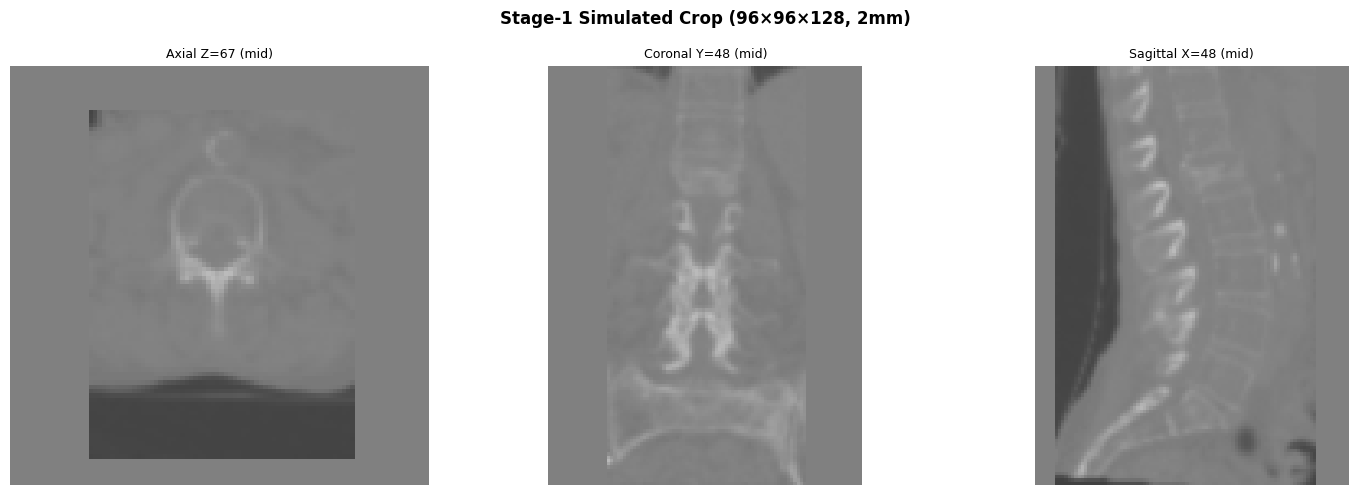

In [5]:
def simulate_stage1_crop(volume, centroids_vox, crop_size=(96, 96, 128), rng=None):
    """
    Simulate Stage-1 output for training.

    Parameters
    ----------
    volume        : np.ndarray  shape (R, A, S)  — 2mm RAS, normalised
    centroids_vox : dict  {label: (ci, cj, ck)}  — 2mm voxel indices
    crop_size     : (CX, CY, CZ) = (96, 96, 128)
    rng           : np.random.Generator or None  (None → random seed)

    Returns
    -------
    crop         : np.ndarray  shape crop_size
    z_start      : int  — Z offset used (needed to re-map centroid coords)
    spine_cx     : int  — spine centre X (i-axis)
    spine_cy     : int  — spine centre Y (j-axis)
    """
    CX, CY, CZ = crop_size
    vol_x, vol_y, vol_z = volume.shape

    if rng is None:
        rng = np.random.default_rng()

    # ── 1. Compute spine centre in X and Y (mean of all GT centroids) ─────────
    all_ci = [v[0] for v in centroids_vox.values()]
    all_cj = [v[1] for v in centroids_vox.values()]
    spine_cx = int(round(np.mean(all_ci)))
    spine_cy = int(round(np.mean(all_cj)))

    # ── 2. Half-widths for X and Y centred crops ──────────────────────────────
    hx, hy = CX // 2, CY // 2
    x0 = spine_cx - hx
    y0 = spine_cy - hy

    # ── 3. Random Z start ─────────────────────────────────────────────────────
    max_z_start = max(vol_z - CZ, 0)
    z_start = int(rng.integers(0, max_z_start + 1)) if max_z_start > 0 else 0

    # ── 4. Extract crop with zero-padding for out-of-bounds ───────────────────
    crop = np.zeros(crop_size, dtype=volume.dtype)

    # X bounds
    xs_vol = max(x0, 0);            xe_vol = min(x0 + CX, vol_x)
    xs_cr  = xs_vol - x0;           xe_cr  = xs_cr + (xe_vol - xs_vol)
    # Y bounds
    ys_vol = max(y0, 0);            ye_vol = min(y0 + CY, vol_y)
    ys_cr  = ys_vol - y0;           ye_cr  = ys_cr + (ye_vol - ys_vol)
    # Z bounds
    zs_vol = z_start;               ze_vol = min(z_start + CZ, vol_z)
    zs_cr  = 0;                     ze_cr  = ze_vol - zs_vol

    crop[xs_cr:xe_cr, ys_cr:ye_cr, zs_cr:ze_cr] = \
        volume[xs_vol:xe_vol, ys_vol:ye_vol, zs_vol:ze_vol]

    return crop, z_start, spine_cx, spine_cy


def remap_centroids_to_crop(centroids_vox, spine_cx, spine_cy, z_start,
                             crop_size=(96, 96, 128)):
    """
    Convert global 2mm voxel centroids → coordinate space of the crop.
    Returns a dict {label: (ci_crop, cj_crop, ck_crop)} where each value
    may be outside [0, crop_size) if that vertebra is not in the Z window.
    """
    CX, CY, CZ = crop_size
    hx, hy = CX // 2, CY // 2
    x0, y0 = spine_cx - hx, spine_cy - hy

    result = {}
    for label, (ci, cj, ck) in centroids_vox.items():
        result[label] = (ci - x0, cj - y0, ck - z_start)
    return result


# ── Demo ─────────────────────────────────────────────────────────────────────
if demo is not None and centroids_2mm:
    rng_demo = np.random.default_rng(42)
    crop_demo, z0, scx, scy = simulate_stage1_crop(
        vol_pp, centroids_2mm, CFG["crop_size"], rng=rng_demo
    )
    crop_centroids = remap_centroids_to_crop(
        centroids_2mm, scx, scy, z0, CFG["crop_size"]
    )

    print(f"Crop shape   : {crop_demo.shape}  (expected {CFG['crop_size']})")
    print(f"Spine centre : X={scx}, Y={scy}")
    print(f"Z start      : {z0}  (Z window [{z0}, {z0+CFG['crop_size'][2]}))")
    print("\nCrop-space centroids (Z inside window iff 0 ≤ ck < 128):")
    for lbl, (ci, cj, ck) in sorted(crop_centroids.items()):
        in_window = 0 <= ck < CFG["crop_size"][2]
        print(f"  label {lbl:3d}: ({ci:4d}, {cj:4d}, {ck:4d})  {'✓ in window' if in_window else '✗ outside Z window'}")

    # ── Quick visualisation ───────────────────────────────────────────────────
    mid_z = CFG["crop_size"][2] // 2
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Stage-1 Simulated Crop (96×96×128, 2mm)", fontsize=12, fontweight="bold")
    for ax, (sl, ttl) in zip(axes, [
        (crop_demo[:, :, mid_z], f"Axial Z={z0+mid_z} (mid)"),
        (crop_demo[:, 48, :],    "Coronal Y=48 (mid)"),
        (crop_demo[48, :, :],    "Sagittal X=48 (mid)"),
    ]):
        ax.imshow(sl.T, cmap="gray", origin="lower", vmin=-1, vmax=1)
        ax.set_title(ttl, fontsize=9); ax.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("⚠ Skipping demo — no subjects loaded.")

## 6. Dataset Class

`SpineDatasetStage2` yields **one sample per subject** (the full-spine crop).  
Each sample:
- `ct_crop`  → `Tensor[1, 96, 96, 128]`
- `gt_centroids_crop` → dict `{label: (ci, cj, ck)}` in crop-space (some may be outside Z window)
- `subject`  → `str`

In [6]:
class SpineDatasetStage2(Dataset):
    """
    One item per subject (full-spine crop, NOT per-vertebra).
    The crop simulates Stage-1 output: centred on spine X,Y; random Z.
    """
    def __init__(self, csv_path, split, crop_size=(96, 96, 128),
                 target_spacing=2.0, sigma=0.75, augment=None):
        self.crop_size      = crop_size
        self.target_spacing = target_spacing
        self.sigma          = sigma
        self.augment        = augment
        self.rng            = np.random.default_rng()

        df       = pd.read_csv(csv_path)
        df_split = df[df["type"] == split].reset_index(drop=True)

        self.rows = []
        for _, row in df_split.iterrows():
            if _is_valid_path(row.get("image_path")) and \
               _is_valid_path(row.get("centroid_json_path")):
                self.rows.append(row)
        print(f"{split.upper()} split: {len(self.rows)} subjects loaded")

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        subj_name = row["name"]

        vol_nib_   = nib.load(str(row["image_path"]))
        mask_nib_  = nib.load(str(row["mask_path"])) \
                     if _is_valid_path(row.get("mask_path")) else None
        _, raw_centroids = parse_centroid_json(str(row["centroid_json_path"]))

        # Preprocess at 2mm
        vol_pp, mask_pp, ras_affine, zooms, orig_affine = full_preprocess(
            vol_nib_, mask_nib_,
            target_spacing=self.target_spacing,
            sigma=self.sigma,
        )

        # Convert JSON centroids → 2mm voxel indices
        centroids_2mm = centroids_to_voxel_2mm(
            raw_centroids, orig_affine, ras_affine, zooms, self.target_spacing
        )
        # Override with mask CoM when available
        for label in list(centroids_2mm.keys()):
            if np.any(mask_pp == label):
                coords = np.array(np.where(mask_pp == label))
                centroids_2mm[label] = tuple(
                    np.round(coords.mean(axis=1)).astype(int)
                )

        # Simulate Stage-1 crop (random Z during training)
        ct_crop, z_start, scx, scy = simulate_stage1_crop(
            vol_pp, centroids_2mm, self.crop_size, rng=self.rng
        )

        # Remap centroids to crop coordinate space
        gt_centroids_crop = remap_centroids_to_crop(
            centroids_2mm, scx, scy, z_start, self.crop_size
        )

        # Optional intensity augmentation
        if self.augment is not None:
            ct_crop = self.augment(ct_crop)

        ct_t = torch.from_numpy(ct_crop[None].astype(np.float32))  # [1,96,96,128]

        return {
            "ct_crop":           ct_t,
            "gt_centroids_crop": gt_centroids_crop,  # dict stays on CPU
            "subject":           subj_name,
        }


# ── Instantiate ───────────────────────────────────────────────────────────────
train_ds = SpineDatasetStage2(CFG["csv_path"], split="train",
                               crop_size=CFG["crop_size"],
                               target_spacing=CFG["target_spacing"],
                               sigma=CFG["smooth_sigma"])
val_ds   = SpineDatasetStage2(CFG["csv_path"], split="val",
                               crop_size=CFG["crop_size"],
                               target_spacing=CFG["target_spacing"],
                               sigma=CFG["smooth_sigma"])
test_ds  = SpineDatasetStage2(CFG["csv_path"], split="test",
                               crop_size=CFG["crop_size"],
                               target_spacing=CFG["target_spacing"],
                               sigma=CFG["smooth_sigma"])

print(f"\nTrain: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

_demo_ds = next((ds for ds in [train_ds, val_ds, test_ds] if len(ds) > 0), None)
if _demo_ds:
    sample = _demo_ds[0]
    print(f"\nSample keys      : {list(sample.keys())}")
    print(f"  ct_crop shape  : {sample['ct_crop'].shape}")
    print(f"  subject        : {sample['subject']}")
    print(f"  GT centroids   : {sample['gt_centroids_crop']}")

TRAIN split: 76 subjects loaded
VAL split: 38 subjects loaded
TEST split: 37 subjects loaded

Train: 76  Val: 38  Test: 37

Sample keys      : ['ct_crop', 'gt_centroids_crop', 'subject']
  ct_crop shape  : torch.Size([1, 96, 96, 128])
  subject        : verse004
  GT centroids   : {16: (np.int64(50), np.int64(40), np.int64(120)), 17: (np.int64(50), np.int64(41), np.int64(109)), 18: (np.int64(49), np.int64(43), np.int64(95)), 19: (np.int64(49), np.int64(45), np.int64(80)), 20: (np.int64(49), np.int64(47), np.int64(67)), 21: (np.int64(48), np.int64(53), np.int64(55)), 22: (np.int64(47), np.int64(56), np.int64(39)), 23: (np.int64(47), np.int64(56), np.int64(24)), 24: (np.int64(46), np.int64(52), np.int64(9))}


## 7. Data Augmentation

Intensity-only augmentation applied to the CT crop (same as Stage 3).  
Spatial augmentation is **not applied here** because:
- Moving the centroid positions after a spatial transform would require updating the GT coordinates, and
- The description only mentions intensity + affine + elastic but does not specify any coordinate update for the multi-heatmap loss — so we stay safe with intensity-only.

In [7]:
class IntensityAugment:
    """
    Intensity-only augmentation: random scale + shift, applied to CT crop only.
    Centroid coordinates are unaffected (intensity changes don't move anatomy).
    """
    def __init__(self, scale=(0.75, 1.25), shift=(-0.25, 0.25)):
        self.scale = scale
        self.shift = shift

    def __call__(self, ct):
        s = np.random.uniform(*self.scale)
        b = np.random.uniform(*self.shift)
        return np.clip(ct * s + b, -1.0, 1.0).astype(np.float32)


train_augment = IntensityAugment(scale=(0.75, 1.25), shift=(-0.25, 0.25))
train_ds.augment = train_augment
print("Intensity augmentation attached to train dataset ✓")

Intensity augmentation attached to train dataset ✓


## 8. SC-Net Architecture

**SpatialConfiguration-Net** as described:

| Branch | Resolution | Kernel | Filters | Activation |
|---|---|---|---|---|
| Local Appearance | Full (96×96×128) | 3×3×3 | 64 | LeakyReLU |
| Spatial Config | 1/4 (24×24×32) | 7×7×7 | 64 | LeakyReLU |

- Local Appearance = **5-level U-Net** structure (2 convs per level, skip connections)
- Spatial Config = **4 consecutive 7×7×7 convolutions** at 1/4 resolution
- Combined (concatenated + 1×1×1 conv) → **25 output heatmap channels**
- **Learned σ** per vertebra: `nn.Parameter` of shape `[25]`, init=5.0

In [8]:
class ConvBlock3D(nn.Module):
    """Two consecutive Conv3d(3×3×3) + LeakyReLU blocks."""
    def __init__(self, in_ch, out_ch=64):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch,  out_ch, kernel_size=3, padding=1, bias=True),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1, bias=True),
            nn.LeakyReLU(0.01, inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class LocalAppearanceUNet(nn.Module):
    """
    5-level U-Net for the Local Appearance branch.
    Input: [B, 1, 96, 96, 128]  — full resolution, single channel CT
    Output: [B, 64, 96, 96, 128]

    Downsampling  : AvgPool3d(2)
    Upsampling    : trilinear Upsample
    Filters       : always 64 (as stated in description)
    """
    def __init__(self, in_channels=1, filters=64):
        super().__init__()
        f = filters
        self.enc1 = ConvBlock3D(in_channels, f)
        self.enc2 = ConvBlock3D(f, f)
        self.enc3 = ConvBlock3D(f, f)
        self.enc4 = ConvBlock3D(f, f)
        self.bottleneck = ConvBlock3D(f, f)
        self.pool = nn.AvgPool3d(2)
        self.up   = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)
        # Decoder: skip-concat doubles channels → 2f → f
        self.dec4 = ConvBlock3D(f * 2, f)
        self.dec3 = ConvBlock3D(f * 2, f)
        self.dec2 = ConvBlock3D(f * 2, f)
        self.dec1 = ConvBlock3D(f * 2, f)

    def forward(self, x):
        e1 = self.enc1(x)                      # [B,64,96,96,128]
        e2 = self.enc2(self.pool(e1))          # [B,64,48,48,64]
        e3 = self.enc3(self.pool(e2))          # [B,64,24,24,32]
        e4 = self.enc4(self.pool(e3))          # [B,64,12,12,16]
        bn = self.bottleneck(self.pool(e4))    # [B,64, 6, 6, 8]
        d4 = self.dec4(torch.cat([self.up(bn), e4], dim=1))   # [B,64,12,12,16]
        d3 = self.dec3(torch.cat([self.up(d4), e3], dim=1))   # [B,64,24,24,32]
        d2 = self.dec2(torch.cat([self.up(d3), e2], dim=1))   # [B,64,48,48,64]
        d1 = self.dec1(torch.cat([self.up(d2), e1], dim=1))   # [B,64,96,96,128]
        return d1


class SpatialConfigBranch(nn.Module):
    """
    Spatial Configuration branch.
    Operates at 1/4 resolution: input is downsampled to (24, 24, 32).
    4 consecutive Conv3d(7×7×7, pad=3) + LeakyReLU.
    Output: [B, 64, 24, 24, 32]  (then upsampled ×4 before combining).
    """
    def __init__(self, in_channels=1, filters=64):
        super().__init__()
        self.branch = nn.Sequential(
            nn.Conv3d(in_channels, filters, kernel_size=7, padding=3, bias=True),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv3d(filters,    filters, kernel_size=7, padding=3, bias=True),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv3d(filters,    filters, kernel_size=7, padding=3, bias=True),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv3d(filters,    filters, kernel_size=7, padding=3, bias=True),
            nn.LeakyReLU(0.01, inplace=True),
        )
        self.down = nn.AvgPool3d(4)  # 1/4 resolution
        self.up   = nn.Upsample(scale_factor=4, mode="trilinear", align_corners=False)

    def forward(self, x):
        x_down  = self.down(x)           # [B, 1, 24, 24, 32]
        feat    = self.branch(x_down)    # [B,64, 24, 24, 32]
        return self.up(feat)             # [B,64, 96, 96,128]


class SCNet(nn.Module):
    """
    SpatialConfiguration-Net.

    Input : [B, 1, 96, 96, 128]  — CT crop at 2mm
    Output: predicted_heatmaps  [B, 25, 96, 96, 128]
            learned_sigmas      [25]  (nn.Parameter)

    The description says features from both branches are combined
    (via concatenation + 1×1×1 conv) before the final 1×1×1 head.
    """
    def __init__(self, in_channels=1, num_classes=25, filters=64,
                 sigma_init=5.0):
        super().__init__()
        self.local_appearance = LocalAppearanceUNet(in_channels, filters)
        self.spatial_config   = SpatialConfigBranch(in_channels, filters)

        # Combine: 64+64 → 64 via 1×1×1, then head 64 → num_classes
        self.combine_conv = nn.Sequential(
            nn.Conv3d(filters * 2, filters, kernel_size=1, bias=True),
            nn.LeakyReLU(0.01, inplace=True),
        )
        self.head = nn.Conv3d(filters, num_classes, kernel_size=1, bias=True)

        # Learned sigmas — one per vertebra, initialised to sigma_init
        self.learned_sigmas = nn.Parameter(
            torch.ones(num_classes) * sigma_init
        )

    def forward(self, x):
        local_feat   = self.local_appearance(x)    # [B,64,96,96,128]
        spatial_feat = self.spatial_config(x)      # [B,64,96,96,128]
        combined     = torch.cat([local_feat, spatial_feat], dim=1)  # [B,128,...]
        combined     = self.combine_conv(combined)  # [B,64,...]
        heatmaps     = self.head(combined)          # [B,25,96,96,128]
        return heatmaps, self.learned_sigmas


# ── Instantiate & sanity check ────────────────────────────────────────────────
device = torch.device(CFG["device"])
model  = SCNet(
    in_channels=1,
    num_classes=CFG["max_vertebrae"],
    filters=64,
    sigma_init=CFG["sigma_init"],
).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model           : SC-Net (Stage 2)")
print(f"Device          : {device}")
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Learned sigmas  : {model.learned_sigmas.shape}  init={model.learned_sigmas[0].item():.1f}")

_dummy = torch.zeros(1, 1, *CFG["crop_size"], device=device)
with torch.no_grad():
    _hm, _sig = model(_dummy)
print(f"\nForward pass OK")
print(f"  input       : {list(_dummy.shape)}")
print(f"  heatmaps    : {list(_hm.shape)}  (one per vertebra)")
print(f"  sigmas      : {list(_sig.shape)}")

Model           : SC-Net (Stage 2)
Device          : cuda
Total params    : 6,572,210
Trainable params: 6,572,210
Learned sigmas  : torch.Size([25])  init=5.0



Forward pass OK
  input       : [1, 1, 96, 96, 128]
  heatmaps    : [1, 25, 96, 96, 128]  (one per vertebra)
  sigmas      : [25]


## 9. Modified L2 Loss with Dynamic GT Heatmap Generation

$$\mathcal{L} = \sum_{i=1}^{25} \left[ \sum_{\mathbf{x}} \left( h_i(\mathbf{x}) - h^*_i(\mathbf{x};\sigma_i) \right)^2 + \alpha \cdot \sigma_i^2 \right]$$

- $h^*_i$ is generated **on-the-fly** using the current **learned** $\sigma_i$
- If vertebra $i$ is **outside the Z-crop window**, its GT heatmap is all zeros
- $\alpha = 100$ penalises large sigmas (prevents heatmaps from becoming flat)

In [9]:
# VerSe19 label range: 1 (C1) … 25 (L6)  →  network index = label - 1
LABEL_TO_IDX = {lbl: lbl - 1 for lbl in range(1, 26)}


def generate_gt_heatmap_3d(centroid_crop, sigma, crop_size):
    """
    Generate a 3-D Gaussian GT heatmap centred at `centroid_crop`.

    Parameters
    ----------
    centroid_crop : (ci, cj, ck) — centroid in crop coordinates
    sigma         : float or torch.Tensor scalar — the *current* learned sigma
    crop_size     : (CX, CY, CZ)

    Returns
    -------
    heatmap : torch.Tensor  shape [CX, CY, CZ], values in [0, 1]
    """
    CX, CY, CZ = crop_size
    ci, cj, ck = centroid_crop

    ii = torch.arange(CX, dtype=torch.float32) - ci
    jj = torch.arange(CY, dtype=torch.float32) - cj
    kk = torch.arange(CZ, dtype=torch.float32) - ck

    gi, gj, gk = torch.meshgrid(ii, jj, kk, indexing="ij")
    dist_sq = gi**2 + gj**2 + gk**2
    sigma_f = sigma.float() if isinstance(sigma, torch.Tensor) else torch.tensor(float(sigma))
    
    # ── Fix: move dist_sq to the same device as sigma_f before calculation ──
    dist_sq = dist_sq.to(sigma_f.device)
    
    heatmap = torch.exp(-dist_sq / (2.0 * sigma_f**2))
    return heatmap  


def modified_l2_loss(predicted_heatmaps, gt_centroids_crop,
                     learned_sigmas, crop_size, alpha=100.0, pos_weight=100.0):

    """
    Modified L2 loss with dynamic GT heatmap generation.

    Parameters
    ----------
    predicted_heatmaps : Tensor [B, 25, CX, CY, CZ]
    gt_centroids_crop  : list of dicts (length B),
                         each dict = {label: (ci, cj, ck)} in crop space
    learned_sigmas     : Tensor [25]  (the nn.Parameter)
    crop_size          : (CX, CY, CZ)
    alpha              : sigma penalty weight (100)

    Returns
    -------
    total_loss : scalar Tensor
    """
    B = predicted_heatmaps.shape[0]
    CX, CY, CZ = crop_size
    device = predicted_heatmaps.device
    total_loss = torch.tensor(0.0, device=device, requires_grad=False)

    # Build loss with autograd by accumulating
    loss_acc = predicted_heatmaps.sum() * 0.0  # keeps grad graph alive

    for b in range(B):
        for vert_idx in range(CFG["max_vertebrae"]):
            label    = vert_idx + 1  # VerSe label (1-based)
            pred_h   = predicted_heatmaps[b, vert_idx]  # [CX,CY,CZ]
            sigma_i  = learned_sigmas[vert_idx]          # scalar Tensor

            # Check if this vertebra is present AND inside the Z window
            centroid = gt_centroids_crop[b].get(label, None)
            in_window = (
                centroid is not None and
                0 <= centroid[2] < CZ   # Z coordinate inside crop
            )

            if in_window:
                gt_h = generate_gt_heatmap_3d(centroid, sigma_i, crop_size)
                gt_h = gt_h.to(device)
            else:
                # Vertebra not visible in this Z crop → blank target
                gt_h = torch.zeros((CX, CY, CZ), device=device)

            # --- NEW: Weighted L2 difference ---
            # Create a weight mask: areas where GT > 0.05 get multiplied by pos_weight
            weight_mask = torch.where(gt_h > 0.05, pos_weight, 1.0)
            
            # Apply weight to squared error
            heatmap_loss = ((pred_h - gt_h) ** 2 * weight_mask).sum()

            # Sigma penalty (forces sigma to stay small)
            sigma_penalty = alpha * (sigma_i ** 2)

            loss_acc = loss_acc + heatmap_loss + sigma_penalty

    return loss_acc / B


# ── Smoke-test ────────────────────────────────────────────────────────────────
torch.manual_seed(42)
_fake_pred   = torch.randn(1, 25, *CFG["crop_size"])
_fake_sigmas = nn.Parameter(torch.ones(25) * 5.0)
_fake_gt     = [{17: (48, 48, 64)}]  # label 17 at crop centre
_test_loss   = modified_l2_loss(_fake_pred, _fake_gt, _fake_sigmas,
                                 CFG["crop_size"], alpha=CFG["alpha"])
print(f"Loss function    : Modified L2 + Sigma Penalty")
print(f"Smoke-test loss  : {_test_loss.item():.4f}")
print("Loss function OK ✓")

Loss function    : Modified L2 + Sigma Penalty
Smoke-test loss  : 30387114.0000
Loss function OK ✓


## 10. Training Loop

- **Optimiser**: Nesterov SGD, lr=1e-8, momentum=0.9, weight_decay=5e-4
- **Batch size**: 1
- **Iterations**: 100 000
- Log train loss every 500 iters; validate every 2 000 iters
- Best model saved on lowest validation loss (no Dice here — output is heatmaps)

In [10]:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=CFG["lr"],
    momentum=CFG["momentum"],
    nesterov=CFG["nesterov"],
    weight_decay=CFG["weight_decay"],
)
print(f"Optimiser: Nesterov SGD  lr={CFG['lr']}  momentum={CFG['momentum']}  "
      f"weight_decay={CFG['weight_decay']}")


def validate_stage2(model, val_loader, crop_size, alpha, device):
    """Run one validation epoch; return mean loss."""
    model.eval()
    losses = []
    with torch.no_grad():
        for batch in val_loader:
            inp      = batch["ct_crop"].to(device)
            gt_list  = batch["gt_centroids_crop"]
            pred_hm, sigmas = model(inp)
            # Pass pos_weight=100.0
            loss = modified_l2_loss(pred_hm, gt_list, sigmas, crop_size, alpha, pos_weight=100.0)
            losses.append(loss.item())
    model.train()
    return float(np.mean(losses)) if losses else float("inf")


def make_loader(ds, shuffle):
    if len(ds) == 0:
        return None
    return DataLoader(ds, batch_size=CFG["batch_size"], shuffle=shuffle,
                      num_workers=2, pin_memory=(device.type == "cuda"),
                      drop_last=True, collate_fn=stage2_collate)


def stage2_collate(batch):
    """
    Custom collate: stack ct_crop tensors normally;
    keep gt_centroids_crop as a plain list of dicts (can't be stacked).
    """
    ct_crops = torch.stack([b["ct_crop"] for b in batch], dim=0)
    gt_list  = [b["gt_centroids_crop"] for b in batch]
    subjects = [b["subject"] for b in batch]
    return {"ct_crop": ct_crops, "gt_centroids_crop": gt_list, "subject": subjects}


train_loader = make_loader(train_ds, shuffle=True)
val_loader   = make_loader(val_ds,   shuffle=False)

if train_loader is None:
    print("⚠ No training samples — using test set as stand-in.")
    _train_dl = make_loader(test_ds, shuffle=True)
else:
    _train_dl = train_loader

if val_loader is None:
    print("⚠ No validation samples — using test set as stand-in.")
    _val_dl = make_loader(test_ds, shuffle=False)
else:
    _val_dl = val_loader


# ── Logging structures ────────────────────────────────────────────────────────
train_log_iters, train_log_loss = [], []
val_log_iters,   val_log_loss   = [], []
best_val_loss   = float("inf")
start_iteration = 1

# ── RESUME LOGIC ──────────────────────────────────────────────────────────────
if CFG["resume_path"] and os.path.exists(CFG["resume_path"]):
    print(f"Loading checkpoint from '{CFG['resume_path']}' ...")
    ckpt = torch.load(CFG["resume_path"], map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    best_val_loss   = ckpt.get("val_loss", float("inf"))
    start_iteration = ckpt.get("iteration", 0) + 1
    print(f"Resumed from iteration {start_iteration}  (best loss={best_val_loss:.4f})")
else:
    print("No checkpoint — starting from scratch.")


# ── Infinite data iterator ─────────────────────────────────────────────────────
def infinite_loader(loader):
    while True:
        for batch in loader:
            yield batch


# ── Training loop ──────────────────────────────────────────────────────────────
print(f"Starting training — {CFG['iterations']:,} iterations")
print("─" * 60)

model.train()
running_loss = 0.0
data_iter    = infinite_loader(_train_dl)

for iteration in range(start_iteration, CFG["iterations"] + 1):
    batch    = next(data_iter)
    inp      = batch["ct_crop"].to(device)          # [B,1,96,96,128]
    gt_list  = batch["gt_centroids_crop"]            # list of dicts

    # Forward pass
    pred_hm, sigmas = model(inp)                    # [B,25,...], [25]
    
    # Loss calculation
    # Include pos_weight=100.0 to fix the under-confidence problem
    loss = modified_l2_loss(pred_hm, gt_list, sigmas,
                             CFG["crop_size"], alpha=CFG["alpha"], pos_weight=100.0)
                             
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    # ── Log training loss ────────────────────────────────────────────────────
    if iteration % CFG["log_every"] == 0:
        avg_loss = running_loss / CFG["log_every"]
        train_log_iters.append(iteration)
        train_log_loss.append(avg_loss)
        running_loss = 0.0
        # Log current sigma range
        sig_min = model.learned_sigmas.min().item()
        sig_max = model.learned_sigmas.max().item()
        print(f"  Iter {iteration:6d}/{CFG['iterations']}  |  "
              f"Train Loss: {avg_loss:.5f}  |  "
              f"σ range [{sig_min:.3f}, {sig_max:.3f}]")

    # ── Validation ───────────────────────────────────────────────────────────
    if iteration % CFG["val_every"] == 0 and _val_dl is not None:
        val_loss = validate_stage2(model, _val_dl,
                                   CFG["crop_size"], CFG["alpha"], device)
        val_log_iters.append(iteration)
        val_log_loss.append(val_loss)
        print(f"  ↳ Val Loss: {val_loss:.5f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                "iteration":       iteration,
                "model_state":     model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "val_loss":        val_loss,
            }, CFG["checkpoint_path"])
            print(f"    ★ New best val loss={val_loss:.5f} — checkpoint saved.")

        # Safety: always save latest
        torch.save({
            "iteration":       iteration,
            "model_state":     model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_loss":        val_loss,
        }, "latest_model_stage2.pth")

print(f"\nTraining complete. Best Val Loss: {best_val_loss:.5f}")

# ── Loss curve ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train_log_iters, train_log_loss, color="royalblue", lw=1.5, label="Train Loss")
if val_log_iters:
    ax.plot(val_log_iters, val_log_loss, color="tomato", lw=1.5,
            linestyle="--", label="Val Loss")
ax.set_xlabel("Iteration"); ax.set_ylabel("Modified L2 Loss")
ax.set_title("Stage 2 — SC-Net Training Loss", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Optimiser: Nesterov SGD  lr=1e-08  momentum=0.9  weight_decay=0.0005
Loading checkpoint from '/kaggle/input/models/ahmedsayad226/seg-stage-2/pytorch/default/1/best_model_stage2.pth' ...


Resumed from iteration 18001  (best loss=29895.2184)
Starting training — 50,000 iterations
────────────────────────────────────────────────────────────


  Iter  18200/50000  |  Train Loss: 107205.99508  |  σ range [3.157, 3.475]


  Iter  18400/50000  |  Train Loss: 85607.68491  |  σ range [3.104, 3.461]


  Iter  18600/50000  |  Train Loss: 78145.24781  |  σ range [3.058, 3.447]


...

  Iter  32800/50000  |  Train Loss: 17853.56519  |  σ range [1.915, 2.595]


  Iter  33000/50000  |  Train Loss: 17767.25952  |  σ range [1.906, 2.584]


  ↳ Val Loss: 27572.51033
    ★ New best val loss=27572.51033 — checkpoint saved.


  Iter  33200/50000  |  Train Loss: 17996.36067  |  σ range [1.896, 2.574]


  Iter  33400/50000  |  Train Loss: 17243.91439  |  σ range [1.887, 2.564]


## 11. Inference — Centroid Detection

At test time:
1. Preprocess the volume (2mm, RAS, smoothed, normalised)
2. Run SC-Net on the full-spine crop (Stage-1 simulation with **fixed** Z = start at 0 or centred)
3. For each of the 25 predicted heatmaps, find the voxel with maximum value → predicted centroid
4. Map the predicted centroid back to world-space (mm)
5. Report the predicted centroids

In [ ]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
if os.path.exists(CFG["checkpoint_path"]):
    ckpt = torch.load(CFG["checkpoint_path"], map_location=device)
    model.load_state_dict(ckpt["model_state"])
    print(f"Loaded checkpoint from iteration {ckpt['iteration']}  "
          f"(val loss={ckpt['val_loss']:.5f})")
else:
    print("No checkpoint found — using current model weights.")

model.eval()


def predict_centroids(model, vol_pp, centroids_2mm, crop_size, device):
    """
    Run inference on a single preprocessed volume.

    At test time we use a deterministic crop:
    - X,Y centred on the spine (using GT centroids if available, else volume centre)
    - Z: start from 0 (the full spine fits in 128 voxels at 2mm for most subjects)

    Returns
    -------
    predicted_centroids_crop  : dict {label: (ci, cj, ck)} in crop space
    predicted_centroids_vol   : dict {label: (ci, cj, ck)} in full-volume space
    heatmaps_np               : np.ndarray [25, CX, CY, CZ]
    """
    CX, CY, CZ = crop_size

    # Deterministic Stage-1 crop: spine centre X,Y, Z=0
    if centroids_2mm:
        scx = int(round(np.mean([v[0] for v in centroids_2mm.values()])))
        scy = int(round(np.mean([v[1] for v in centroids_2mm.values()])))
    else:
        scx, scy = vol_pp.shape[0] // 2, vol_pp.shape[1] // 2

    # Use a fixed z_start=0 (whole-spine inference)
    rng_fixed = np.random.default_rng(0)
    ct_crop, z_start, scx_used, scy_used = simulate_stage1_crop(
        vol_pp, centroids_2mm if centroids_2mm else {0: (scx, scy, 0)},
        crop_size, rng=rng_fixed
    )

    inp_t = torch.from_numpy(ct_crop[None, None].astype(np.float32)).to(device)

    with torch.no_grad():
        pred_hm, _ = model(inp_t)          # [1,25,CX,CY,CZ]
    heatmaps_np = pred_hm[0].cpu().numpy()  # [25,CX,CY,CZ]

    pred_centroids_crop = {}
    pred_centroids_vol  = {}
    for vert_idx in range(CFG["max_vertebrae"]):
        label = vert_idx + 1
        hm    = heatmaps_np[vert_idx]               # [CX,CY,CZ]
        # conf = np.max(hm)
        # if conf < 0.05:  # Updated threshold as per your testing
        #     continue  
        flat_idx = np.argmax(hm)
        ci_c, cj_c, ck_c = np.unravel_index(flat_idx, hm.shape)
        pred_centroids_crop[label] = (int(ci_c), int(cj_c), int(ck_c))

        # Map back to full-volume space
        hx, hy = CX // 2, CY // 2
        x0 = scx_used - hx; y0 = scy_used - hy
        ci_v = ci_c + x0
        cj_v = cj_c + y0
        ck_v = ck_c + z_start
        pred_centroids_vol[label] = (int(ci_v), int(cj_v), int(ck_v))

    return pred_centroids_crop, pred_centroids_vol, heatmaps_np


# ── Run on test subjects ──────────────────────────────────────────────────────
df_test = pd.read_csv(CFG["csv_path"])
df_test = df_test[df_test["type"] == "test"].reset_index(drop=True)

all_results = []  # collect (subject, label, pred_vox, gt_vox) for evaluation

for _, row in df_test.iterrows():
    subj_name = row["name"]
    print(f"\nInference: {subj_name}")
    try:
        vol_nib_  = nib.load(str(row["image_path"]))
        mask_nib_ = nib.load(str(row["mask_path"])) \
                    if _is_valid_path(row.get("mask_path")) else None
        _, raw_centroids = parse_centroid_json(str(row["centroid_json_path"]))

        vol_pp, mask_pp, ras_affine, zooms, orig_affine = full_preprocess(
            vol_nib_, mask_nib_,
            target_spacing=CFG["target_spacing"],
            sigma=CFG["smooth_sigma"],
        )
        centroids_2mm_ = centroids_to_voxel_2mm(
            raw_centroids, orig_affine, ras_affine, zooms, CFG["target_spacing"]
        )
        # Override with mask CoM
        for label in list(centroids_2mm_.keys()):
            if np.any(mask_pp == label):
                coords = np.array(np.where(mask_pp == label))
                centroids_2mm_[label] = tuple(
                    np.round(coords.mean(axis=1)).astype(int)
                )

        pred_crop, pred_vol, heatmaps_np = predict_centroids(
            model, vol_pp, centroids_2mm_, CFG["crop_size"], device
        )
        
        print(f"  {'Label':>6}  {'GT (vox)':>22}  {'Pred (vox)':>22}  {'Error (vox)':>14}")
        print(f"  {'─'*6}  {'─'*22}  {'─'*22}  {'─'*14}")
        for label in sorted(centroids_2mm_.keys()):
            gt_v  = np.array(centroids_2mm_[label])
            
            # --- FIXED: Only calculate error for detected vertebrae ---
            if label in pred_vol:
                pr_v  = np.array(pred_vol[label])
                err   = np.linalg.norm(gt_v - pr_v)
                all_results.append({"subject": subj_name, "label": label,
                                     "gt_vox": gt_v, "pred_vox": pr_v, "error_vox": err})
                print(f"  {label:6d}  {str(tuple(gt_v)):>22}  {str(tuple(pr_v)):>22}  {err:>14.1f}")
            else:
                print(f"  {label:6d}  {str(tuple(gt_v)):>22}  {'Not Found':>22}  {'-':>14}")

        # ── Visualise: predicted centroids on Sagittal and Coronal views ─────────────
        mid_x = vol_pp.shape[0] // 2  # Sagittal cut
        mid_y = vol_pp.shape[1] // 2  # Coronal cut
        
        fig, axes = plt.subplots(2, 2, figsize=(12, 12))
        
        # 1) Sagittal View Volume (Y, Z plane)
        ax_sag = axes[0, 0]
        ax_sag.imshow(vol_pp[mid_x, :, :].T, cmap="gray", origin="lower", vmin=-1, vmax=1)
        for label, (ci, cj, ck) in pred_vol.items():
            ax_sag.plot(cj, ck, "r+", markersize=8, markeredgewidth=1.5)
            ax_sag.text(cj + 2, ck, str(label), color="yellow", fontsize=7)
        for label, (ci, cj, ck) in centroids_2mm_.items():
            ax_sag.plot(cj, ck, "g+", markersize=8, markeredgewidth=1.5)
        ax_sag.set_title(f"{subj_name} — Sagittal (mid X)\nRed=Predicted  Green=GT", fontsize=10)
        ax_sag.axis("off")

        # 2) Coronal View Volume (X, Z plane)
        ax_cor = axes[0, 1]
        ax_cor.imshow(vol_pp[:, mid_y, :].T, cmap="gray", origin="lower", vmin=-1, vmax=1)
        for label, (ci, cj, ck) in pred_vol.items():
            ax_cor.plot(ci, ck, "r+", markersize=8, markeredgewidth=1.5)
            ax_cor.text(ci + 2, ck, str(label), color="yellow", fontsize=7)
        for label, (ci, cj, ck) in centroids_2mm_.items():
            ax_cor.plot(ci, ck, "g+", markersize=8, markeredgewidth=1.5)
        ax_cor.set_title(f"{subj_name} — Coronal (mid Y)\nRed=Predicted  Green=GT", fontsize=10)
        ax_cor.axis("off")

        # Combine all 25 heatmaps by taking the maximum confidence at each voxel
        # Shape becomes [CX, CY, CZ]
        combined_hm = np.max(heatmaps_np, axis=0) 
        
        # 3) Heatmap Sagittal MIP (Project over X axis of the crop)
        ax_hm_sag = axes[1, 0]
        hm_sag_mip = np.max(combined_hm, axis=0) # [CY, CZ]
        im_sag = ax_hm_sag.imshow(hm_sag_mip.T, cmap="magma", origin="lower")
        ax_hm_sag.set_title(f"Raw Heatmaps MIP (Sagittal Crop)\nMax Conf: {combined_hm.max():.4f}", fontsize=10)
        fig.colorbar(im_sag, ax=ax_hm_sag, fraction=0.046, pad=0.04)
        ax_hm_sag.axis("off")

        # 4) Heatmap Coronal MIP (Project over Y axis of the crop)
        ax_hm_cor = axes[1, 1]
        hm_cor_mip = np.max(combined_hm, axis=1) # [CX, CZ]
        im_cor = ax_hm_cor.imshow(hm_cor_mip.T, cmap="magma", origin="lower")
        ax_hm_cor.set_title(f"Raw Heatmaps MIP (Coronal Crop)\nMax Conf: {combined_hm.max():.4f}", fontsize=10)
        fig.colorbar(im_cor, ax=ax_hm_cor, fraction=0.046, pad=0.04)
        ax_hm_cor.axis("off")
        
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"  ✗ Error: {e}")

print(f"\nInference complete. {len(all_results)} vertebra results.")

## 12. Evaluation — Mean Localization Error (MLE)

Standard metric for centroid detection: Euclidean distance in voxels (at 2mm = multiply by 2 for mm).

In [ ]:
if all_results:
    df_eval = pd.DataFrame([
        {"subject": r["subject"], "label": r["label"],
         "error_vox": r["error_vox"],
         "error_mm":  r["error_vox"] * CFG["target_spacing"]}
        for r in all_results
    ])

    print("── Per-vertebra localization error ──────────────────────────────")
    print(df_eval[["subject", "label", "error_vox", "error_mm"]].to_string(index=False))
    print(f"\nMean error (voxels): {df_eval['error_vox'].mean():.2f}  ± {df_eval['error_vox'].std():.2f}")
    print(f"Mean error (mm)    : {df_eval['error_mm'].mean():.2f}  ± {df_eval['error_mm'].std():.2f}")

    # Bar chart
    labels_sorted = sorted(df_eval["label"].unique())
    mean_err = [df_eval[df_eval["label"] == l]["error_mm"].mean() for l in labels_sorted]

    fig, ax = plt.subplots(figsize=(max(10, len(labels_sorted) * 1.1), 4))
    ax.bar(range(len(labels_sorted)), mean_err, color="steelblue")
    ax.set_xticks(range(len(labels_sorted)))
    ax.set_xticklabels([f"L{l}" for l in labels_sorted], rotation=45, ha="right")
    ax.set_ylabel("Mean Localization Error (mm)")
    ax.set_title("Stage 2 — Per-Vertebra Localization Error", fontweight="bold")
    ax.axhline(df_eval['error_mm'].mean(), color="tomato", lw=1.5,
               linestyle="--", label=f"Mean={df_eval['error_mm'].mean():.2f}mm")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("No results to evaluate. Run inference first.")